# Week 9: Rasch 모델의 기본 원리

## 학습 목표
Rasch 모델의 수리적 이해와 곡선.

## 이론적 배경 (Mathematical Background)

Rasch Model (1PL):  

$$ 
    P(X_{ni} = 1) = \frac{\exp(\theta_n - \delta_i)}{1 + \exp(\theta_n - \delta_i)} 
$$  

- $\theta_n$: Person Ability  
- $\delta_i$: Item Difficulty

## 데이터 시뮬레이션 (Data Simulation)
Python을 사용하여 가상의 데이터를 생성합니다.

In [1]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 능력치(theta) 범위
theta = np.linspace(-4, 4, 100)
# 문항 난이도
item_diff_1 = 0.0
# 확률 계산
prob_1 = sigmoid(theta - item_diff_1)

## 결과 시뮬레이션 및 가시화 (Visualization)
생성된 데이터 또는 분석 결과를 시각화합니다.

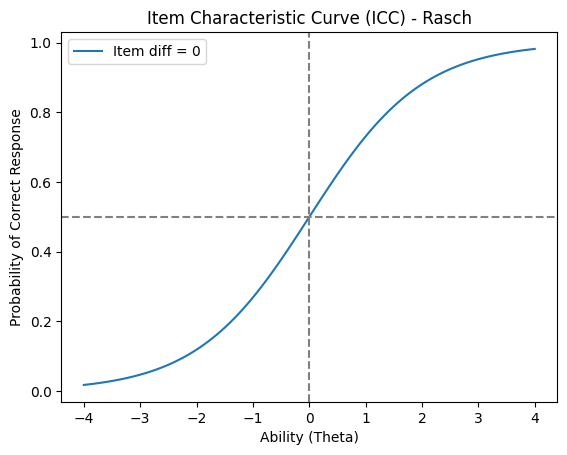

In [2]:
import matplotlib.pyplot as plt

plt.plot(theta, prob_1, label='Item diff = 0')
plt.axvline(x=0, color='gray', linestyle='--')
plt.axhline(y=0.5, color='gray', linestyle='--')
plt.title('Item Characteristic Curve (ICC) - Rasch')
plt.xlabel('Ability (Theta)')
plt.ylabel('Probability of Correct Response')
plt.legend()
plt.show()

# Rasch Measurement (CMLE + Stan)

> Goal: build Rasch measurement end-to-end, and show that (i) CMLE-based estimation, (ii) Stan `optimize()` (MAP), and (iii) Stan MCMC posterior means give practically the same estimates (up to the usual location constraint).

We will do the following (one task per cell):
1. Implement a CMLE algorithm for Rasch measurement (item parameters).
2. Simulate data: 30 items and 150 persons (fixed seed).
3. Run CMLE to estimate item difficulties and then estimate person abilities; draw a Wright map.
4. Fit a comparable Rasch model in Stan and run CmdStanPy `optimize()`; compare against CMLE.
5. Run MCMC; use posterior means as point estimates; compare against the two above.
6. Rasch diagnostics: infit/outfit (math + intuition + computation).
7. Invariance: explanation + split-sample invariance check with uncertainty ellipses.
8. Wright map + “Pathway map” (Bond & Fox style visual summaries).
9. References and tutorials.

In [3]:
# Setup: imports + reproducibility
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Tuple

from scipy.special import expit  # logistic sigmoid
from scipy.optimize import minimize

# Reproducibility
SEED = 510100
rng = np.random.default_rng(SEED)

plt.rcParams.update({"figure.dpi": 300})

Simulated response matrix X shape: (150, 30)
Item difficulties delta_true: mean=0.000, sd=0.816
Person abilities beta_true: mean=0.038, sd=1.082
Overall proportion correct: 0.497


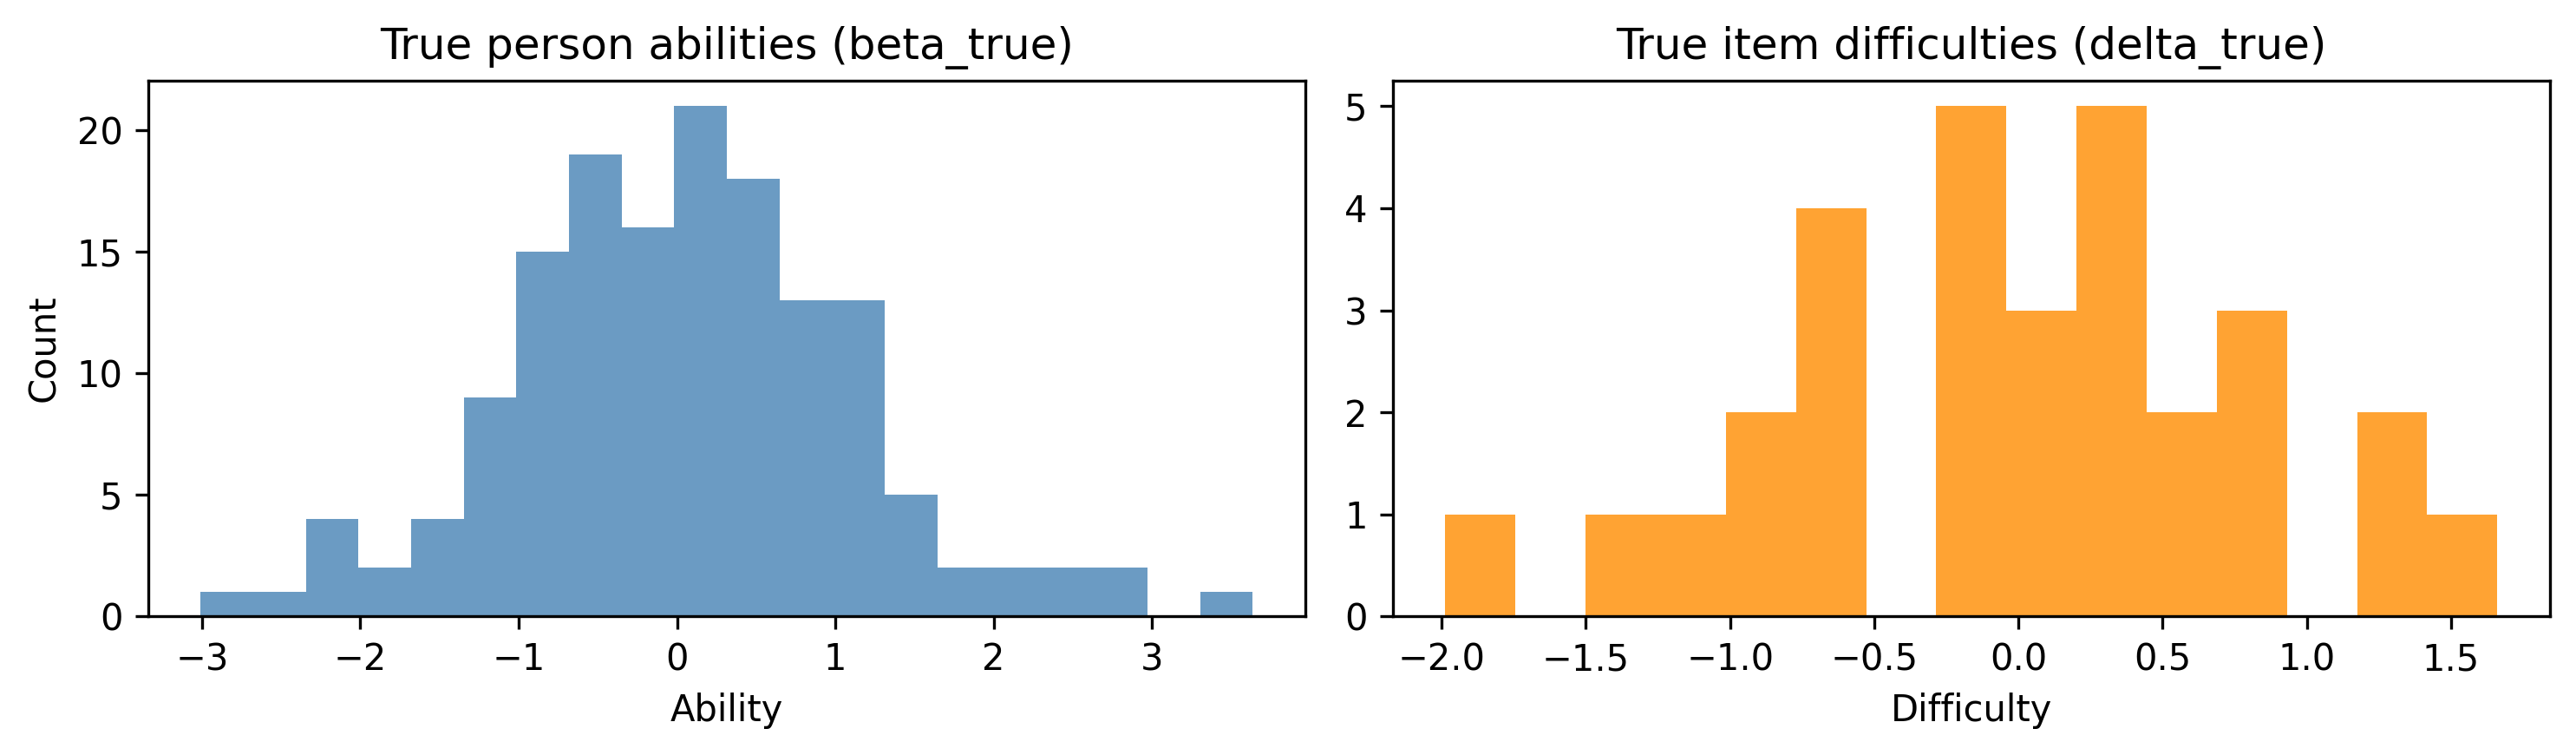

In [4]:
# Simulate Rasch data: 30 item difficulties (delta) and 150 person abilities (beta)
N_PERSON = 150
J_ITEM = 30

# True parameters (location is arbitrary; we center item difficulties for identifiability)
delta_true = rng.normal(loc=0.0, scale=1.0, size=J_ITEM)
delta_true = delta_true - delta_true.mean()
beta_true = rng.normal(loc=0.0, scale=1.0, size=N_PERSON)

# Rasch model: P(X_nj = 1) = logistic(beta_n - delta_j)
# beta (person) [N, 1] - delta (item) [1, J]
p = expit(beta_true[:, None] - delta_true[None, :])
X = rng.binomial(n=1, p=p, size=(N_PERSON, J_ITEM)).astype(int)

print("Simulated response matrix X shape:", X.shape)
print("Item difficulties delta_true: mean=%.3f, sd=%.3f" % (delta_true.mean(), delta_true.std(ddof=1)))
print("Person abilities beta_true: mean=%.3f, sd=%.3f" % (beta_true.mean(), beta_true.std(ddof=1)))
print("Overall proportion correct: %.3f" % (X.mean(),))

# Quick sanity plots
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(beta_true, bins=20, alpha=0.8, color="steelblue")
ax[0].set_title("True person abilities (beta_true)")
ax[0].set_xlabel("Ability")
ax[0].set_ylabel("Count")
ax[1].hist(delta_true, bins=15, alpha=0.8, color="darkorange")
ax[1].set_title("True item difficulties (delta_true)")
ax[1].set_xlabel("Difficulty")
plt.tight_layout()
plt.show()

# 1 & 2. CMLE Implementation & Estimation

We define a class `SimpleRaschCMLE` that:
1.  Computes **Elementary Symmetric Functions (ESF)** recursively.
2.  Defines the **Conditional Log-Likelihood (CLL)** of observing the total item scores given person raw scores.
3.  Optimizes item difficulties $\delta$ minimizing negative CCL.
4.  Estimates person abilities $\beta$ via MLE (Test Characteristic Curve inversion) using the fixed $\hat{\delta}$.

$$ L_c(\delta) \propto \frac{\prod_{j} \exp(-\delta_j S_j)}{\prod_{r=0}^J \gamma_r(\delta)^{n_r}} $$

where $S_j$ is the sum of scores for item $j$ (item sufficient statistic), and $n_r$ is the count of persons with raw score $r$.

In [5]:
class SimpleRaschCMLE:
    def __init__(self, X: np.ndarray):
        self.X = X
        self.N, self.J = X.shape
        self.person_scores = X.sum(axis=1)
        self.item_totals = X.sum(axis=0)
        self.delta_hat = None # Item difficulties
        self.beta_hat = None  # Person abilities
        self.se_delta = None
        self.se_beta = None

    def _compute_esf_recursive(self, epsilon: np.ndarray) -> np.ndarray:
        # gamma[k] is the ESF of order k for the given epsilon values
        # Algorithm: Lord & Wingersky (1984) / Liou (1994)
        J = len(epsilon)
        gamma = np.zeros(J + 1)
        gamma[0] = 1.0
        
        for j in range(J):
            eps_j = epsilon[j]
            # Update gamma in place (backwards to avoid overwriting needed values)
            for k in range(j + 1, 0, -1):
                gamma[k] = gamma[k] + eps_j * gamma[k-1]
        return gamma

    def _neg_conditional_loglik(self, delta_constrained: np.ndarray) -> float:
        # Constraint: sum(delta) = 0.
        # Construct full delta vector (delta_J = -sum(delta_0..J-1))
        delta_full = np.concatenate([delta_constrained, [-np.sum(delta_constrained)]])
        epsilon = np.exp(-delta_full)
        
        # Compute ESF
        gamma = self._compute_esf_recursive(epsilon) # size J+1
        
        # Log-Likelihood term 1: - sum(delta_j * S_j)
        term1 = -np.sum(delta_full * self.item_totals)
        
        # Log-Likelihood term 2: - sum(n_r * log(gamma_r))
        # n_r is count of persons with score r
        term2 = 0.0
        counts = np.bincount(self.person_scores, minlength=self.J + 1)
        
        log_gamma = np.log(gamma + 1e-100)
        term2 = -np.sum(counts * log_gamma)
        
        # We minimize NEGATIVE loglik
        return -(term1 + term2)

    def fit_item_params(self):
        # Initial guess: 0 for J-1 items
        initial_guess = np.zeros(self.J - 1)
        
        res = minimize(self._neg_conditional_loglik, initial_guess, method='BFGS')
        
        delta_constrained = res.x
        self.delta_hat = np.concatenate([delta_constrained, [-np.sum(delta_constrained)]])
        
        return self.delta_hat

    def fit_person_params(self):
        if self.delta_hat is None:
            raise ValueError("Fit item params first.")
        
        # For each raw score r, find beta that satisfies E[score] = r
        score_to_beta = {}
        
        for r in range(1, self.J):
            # Solve f(beta) = sum(prob) - r = 0
            def func(beta_val):
                p_probs = expit(beta_val - self.delta_hat)
                return np.sum(p_probs) - r
            
            # Root finding
            from scipy.optimize import root_scalar
            sol = root_scalar(func, bracket=[-10, 10], method='brentq')
            score_to_beta[r] = sol.root
        
        # Handle r=0 and r=J (proximal correction)
        def correct_extreme(target_r):
             def func(beta_val):
                 p_probs = expit(beta_val - self.delta_hat)
                 return np.sum(p_probs) - target_r
             sol = root_scalar(func, bracket=[-10, 10], method='brentq')
             return sol.root
        
        score_to_beta[0] = correct_extreme(0.3)
        score_to_beta[self.J] = correct_extreme(self.J - 0.3)
        
        # Map back to persons
        self.beta_hat = np.array([score_to_beta[s] for s in self.person_scores])
        return self.beta_hat

CMLE Delta (Item, first 5): [ 1.3618799   0.15378187  0.18602036  0.21832162 -0.73037749]
CMLE Beta (Person, first 5): [ 0.96270261 -0.44964133 -0.44964133  1.79343042 -0.29378721]
Corr(delta_true, delta_cmle): 0.9699
Corr(beta_true, beta_cmle): 0.9079


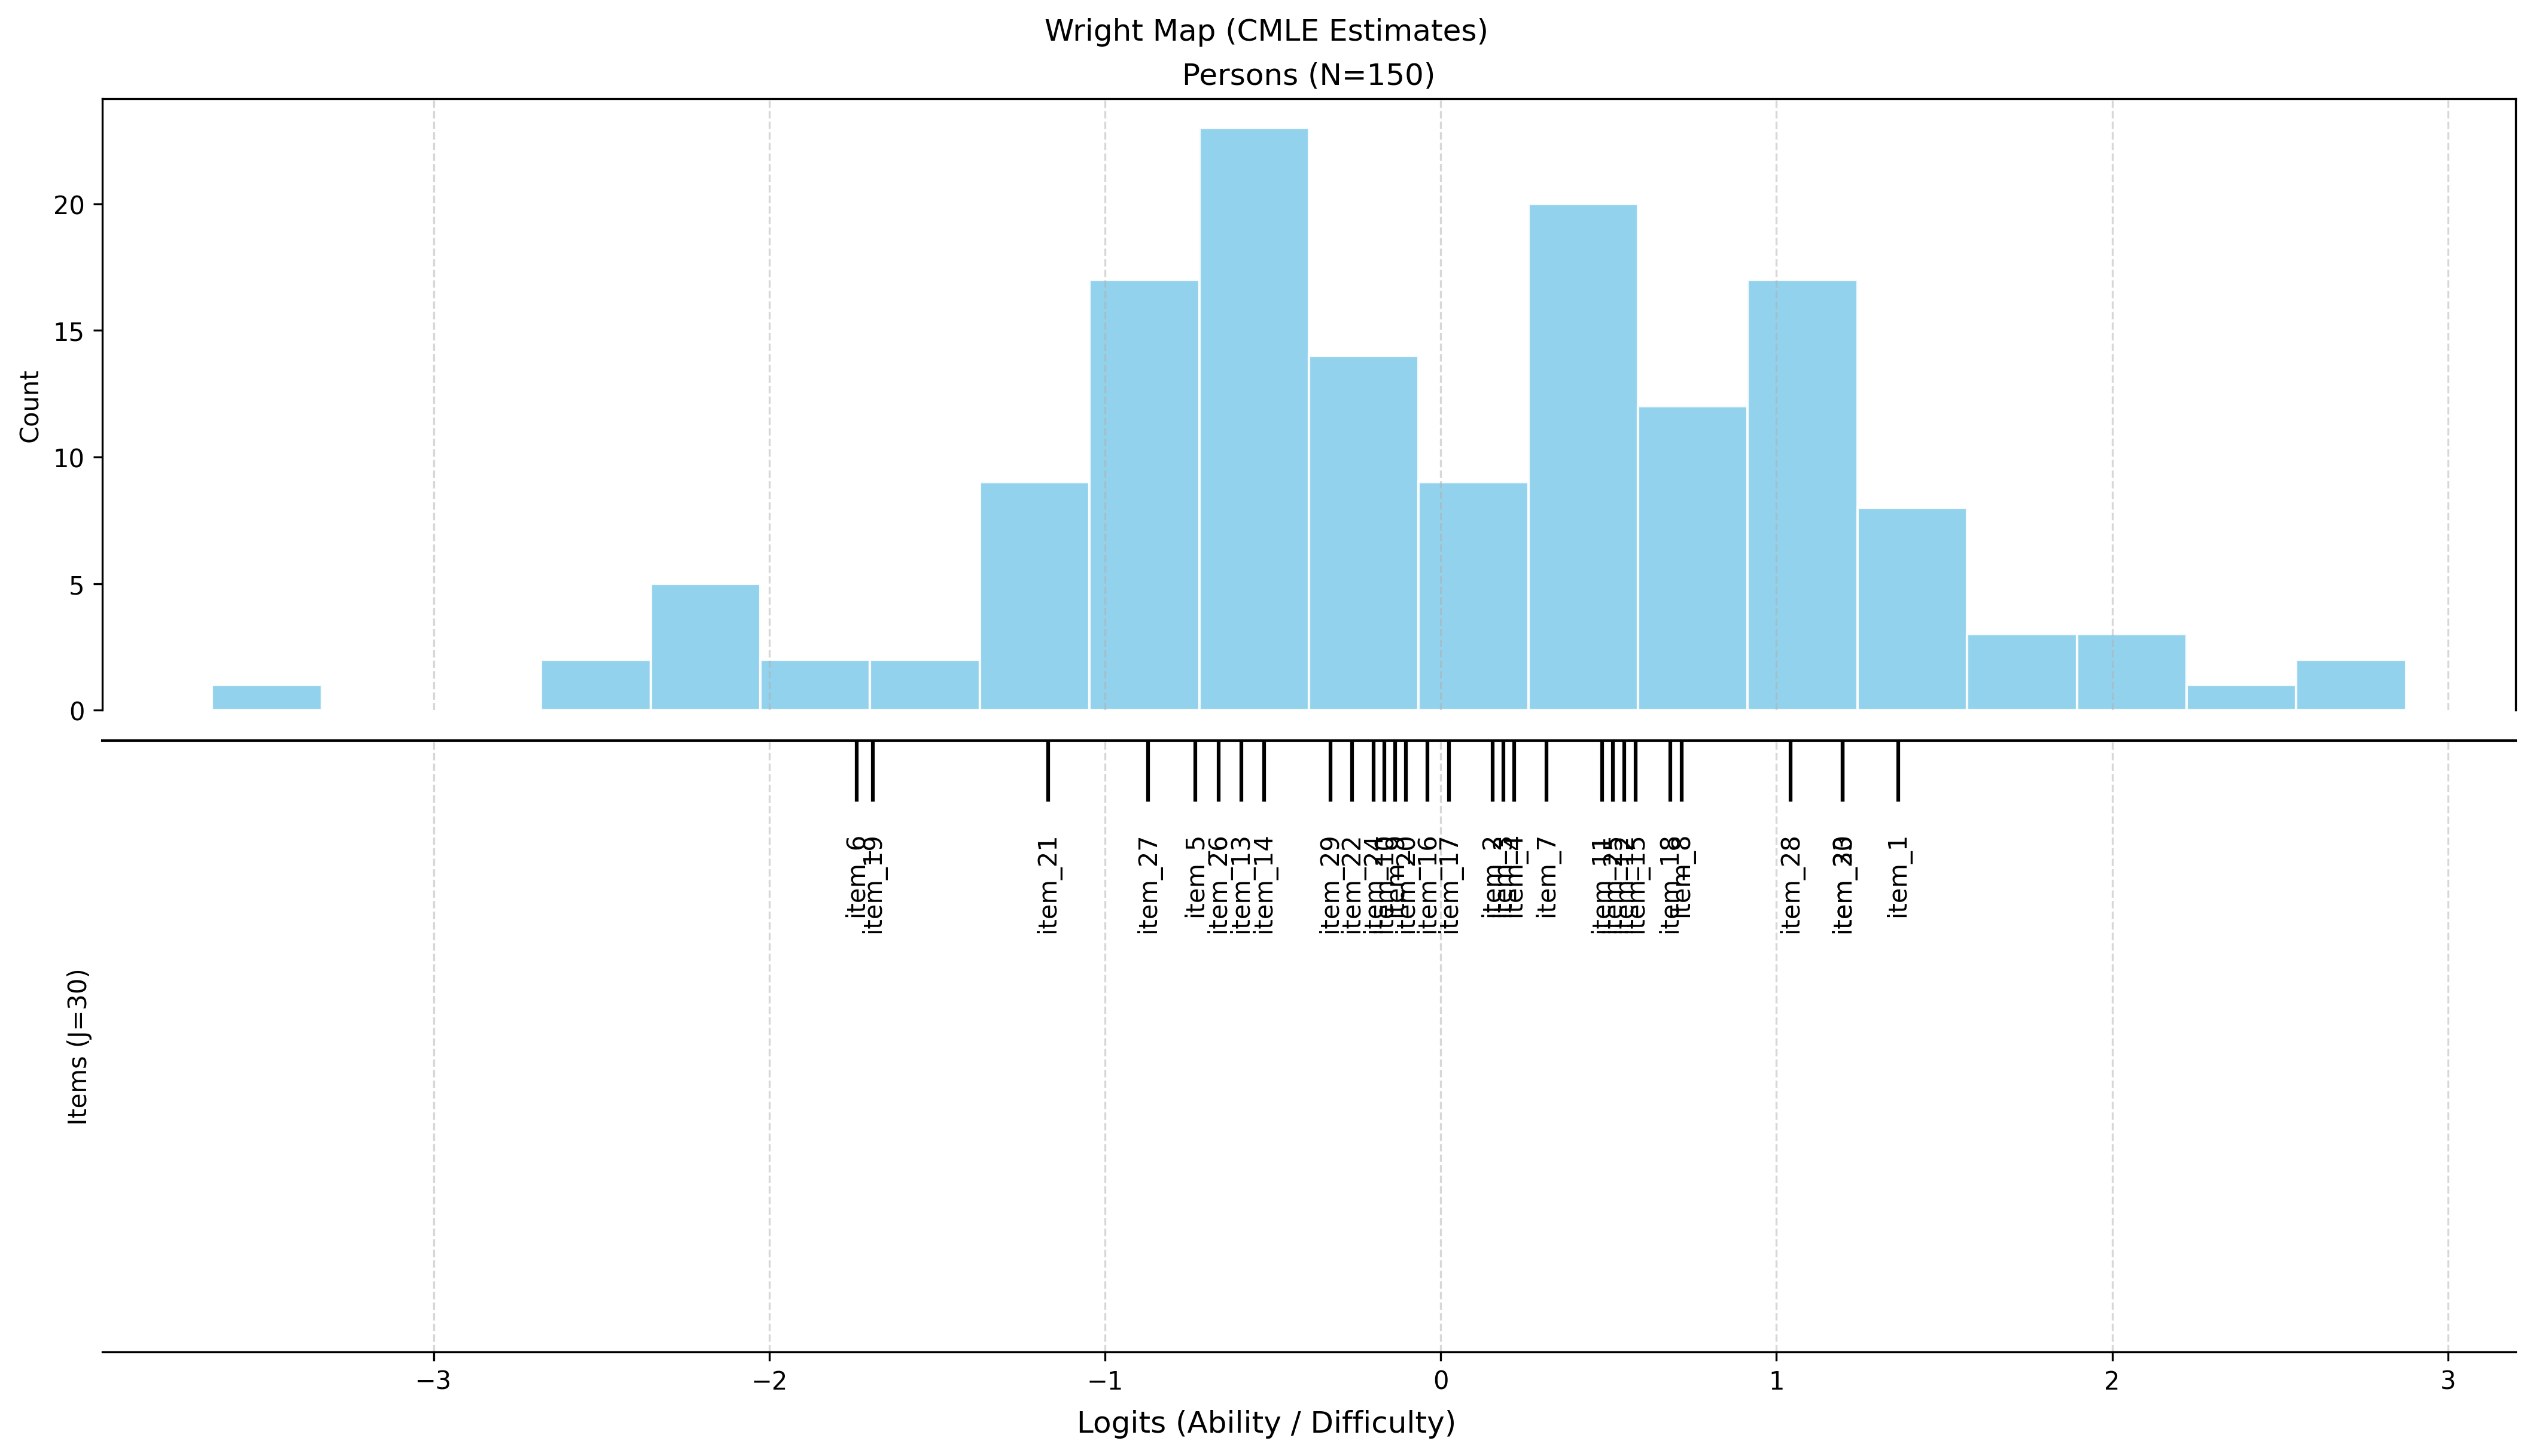

In [6]:
# 3. Run CMLE and Draw Wright Map
cmle_model = SimpleRaschCMLE(X)
delta_cmle = cmle_model.fit_item_params()
beta_cmle = cmle_model.fit_person_params()

print("CMLE Delta (Item, first 5):", delta_cmle[:5])
print("CMLE Beta (Person, first 5):", beta_cmle[:5])

# Correlation with true values
print(f"Corr(delta_true, delta_cmle): {np.corrcoef(delta_true, delta_cmle)[0,1]:.4f}")
print(f"Corr(beta_true, beta_cmle): {np.corrcoef(beta_true, beta_cmle)[0,1]:.4f}")

# Create a reusable Wright Map function
# Updated: Rotated Wright Map (Logits on X-axis) to maximize space and reduce label overlap
# parameters: person_abilities (beta), item_difficulties (delta)
def plot_wright_map(person_abilities, item_difficulties, item_names=None, title="Wright Map"):
    # Use constrained_layout
    # Rotated: Logits on X-axis (Horizontal)
    # hspace=0.0 brings the plots together to form a central axis
    fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True, gridspec_kw={'hspace': 0.0, 'height_ratios': [1, 1]})
    
    # Person histogram (Top)
    # Orientation vertical (default) for horizontal axis
    ax[0].hist(person_abilities, bins=20, color='skyblue', edgecolor='white', alpha=0.9, label='Persons')
    ax[0].set_title(f"Persons (N={len(person_abilities)})")
    ax[0].set_ylabel("Count")
    ax[0].grid(axis='x', linestyle='--', alpha=0.5)
    
    # Remove bottom spine to join with item plot
    ax[0].spines['bottom'].set_visible(False)
    # Hide x ticks on top plot (handled by sharex but good to be explicit about visual separation)
    ax[0].tick_params(axis='x', bottom=False, labelbottom=False)

    # Item Strip Plot (Bottom)
    ax[1].set_ylim(0, 1)
    
    if item_names is None:
        item_names = [f"item_{j+1}" for j in range(len(item_difficulties))]

    # Draw vertical ticks for items (hanging from top of the bottom plot, which is the shared axis)
    tick_length = 0.1
    ax[1].vlines(x=item_difficulties, ymin=1.0 - tick_length, ymax=1.0, color='black', linewidth=1.5, zorder=3)

    # Add labels below the ticks
    # Rotated 90 degrees to permit denser packing
    for j, d in enumerate(item_difficulties):
        name = item_names[j] if j < len(item_names) else f"item_{j+1}"
        ax[1].text(d, 1.0 - tick_length - 0.05, name, ha='center', va='top', rotation=90, fontsize=10, color='black', zorder=4)

    ax[1].set_ylabel(f"Items (J={len(item_difficulties)})")
    ax[1].set_yticks([]) # Remove y-ticks for items
    
    # Bottom plot spines
    ax[1].spines['top'].set_visible(True) # This acts as the main axis line
    ax[1].spines['top'].set_linewidth(1.0)
    ax[1].spines['right'].set_visible(False)
    ax[1].spines['left'].set_visible(False)
    ax[1].spines['bottom'].set_visible(True)
    
    ax[1].grid(axis='x', linestyle='--', alpha=0.5)
    
    # Shared labels
    fig.supxlabel("Logits (Ability / Difficulty)")
    fig.suptitle(title)
    
    plt.show()

plot_wright_map(beta_cmle, delta_cmle, title="Wright Map (CMLE Estimates)")

In [7]:
delta_true, delta_true[-1], delta_cmle[-1], min(delta_true), min(delta_cmle)

(array([ 1.28783108,  0.27000781,  0.02086842,  0.34255655, -0.82431893,
        -1.48980689,  0.34985915,  0.71098328, -0.07541156, -0.27177987,
         0.70701862,  0.45002993, -0.56579801, -0.70326379,  0.46389757,
         0.10359771, -0.10567037,  0.41671332, -1.98712312, -0.13673265,
        -1.10239837,  0.09031319,  1.66067292, -0.08192478,  0.34740054,
        -0.88260687, -0.561877  ,  0.75425266, -0.55447146,  1.36718094]),
 1.3671809405477493,
 1.1978643567481513,
 -1.9871231164013161,
 -1.740031797758298)

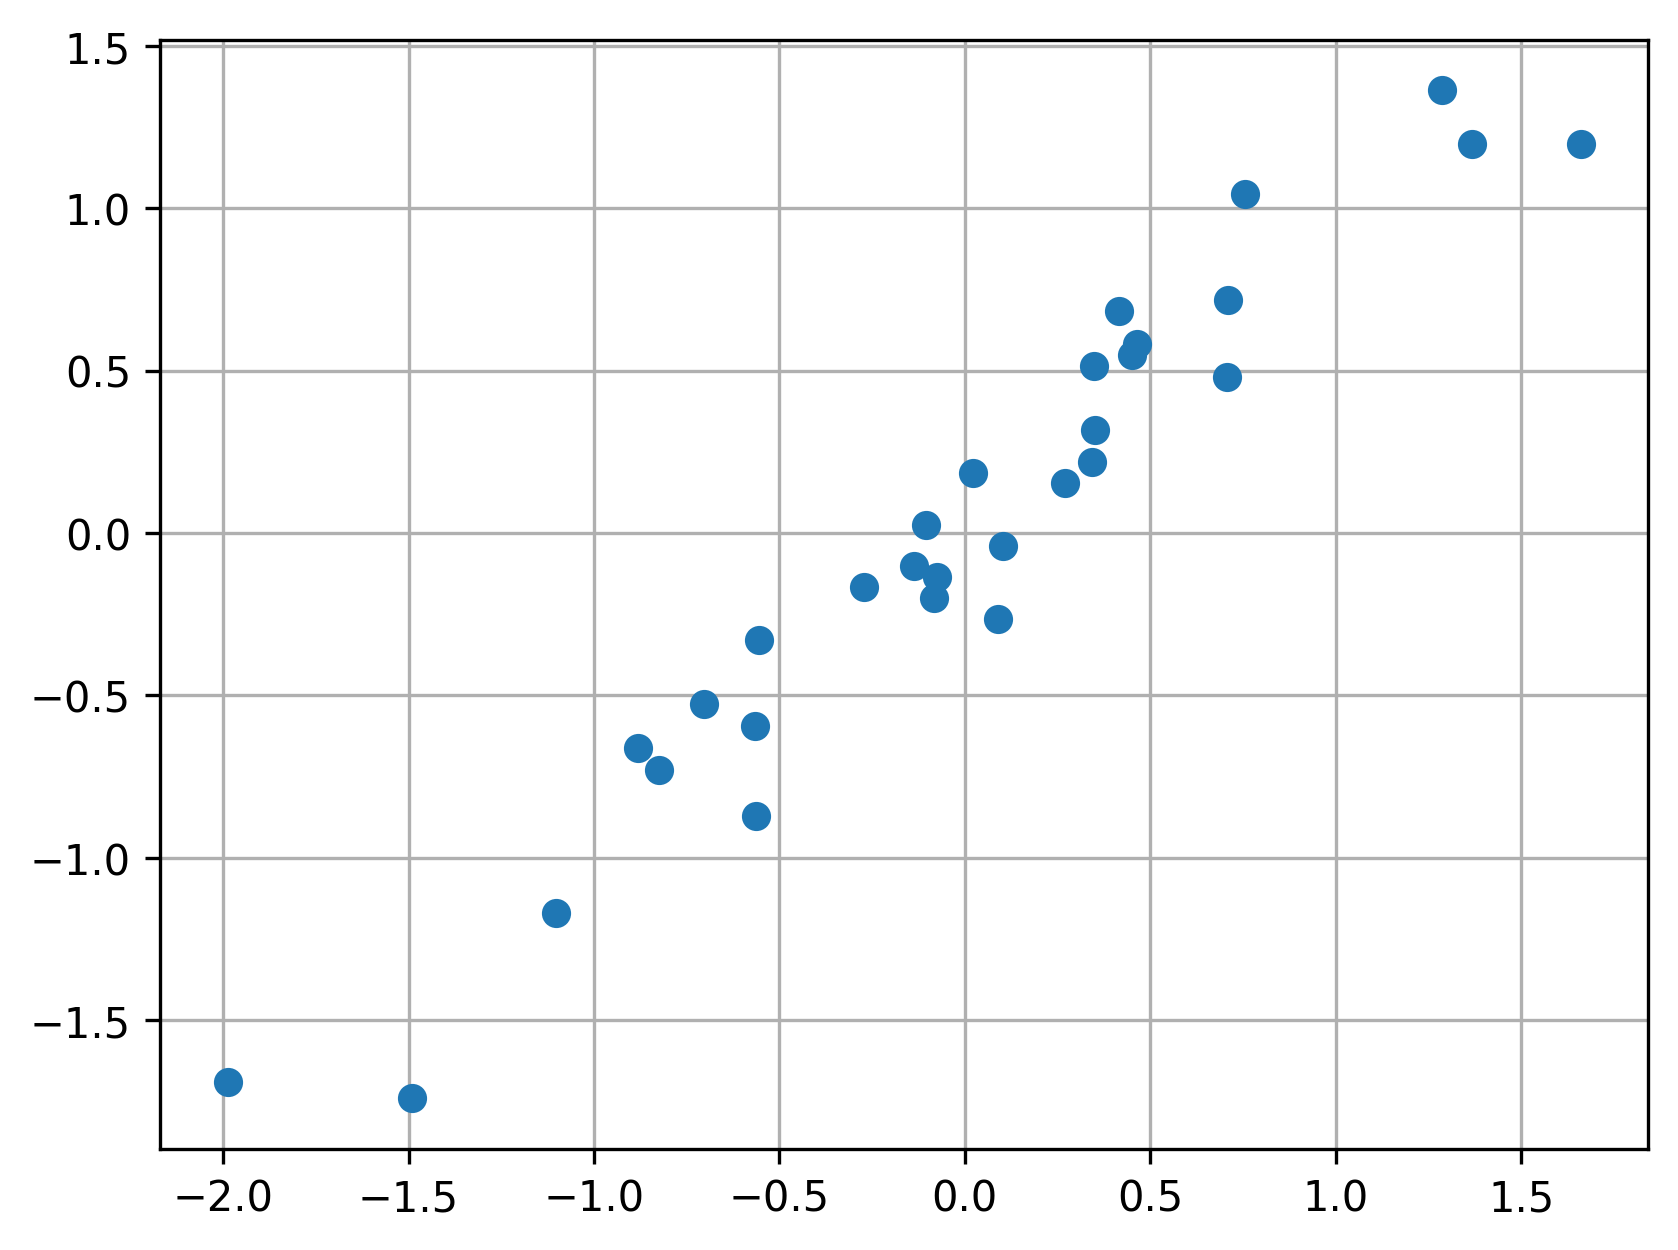

In [8]:
plt.plot(delta_true, delta_cmle, 'o'); plt.grid(True);

# 4. Stan `optimize()` (MAP/JML) vs CMLE

We define a standard Rasch model in Stan:
$$ P(X_{ni}=1) = \text{logit}^{-1}(\beta_n - \delta_j) $$
To correct for the "floating scale," we constrain $\sum \delta_j = 0$ (sum-to-zero).
We use **weakly informative priors** (Standard Normal) to regularize the estimates, effectively performing MAP estimation.

Note: In small samples (short tests), JML (estimating $N+J$ params) can be biased. CMLE removes $\beta$ to estimate $\delta$. We expect Stan MAP estimates to be very close to CMLE if priors are flat, or slightly shrinkage-biased if J is small.

17:42:39 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\Downloads\KOS5101\Weekly_Notebooks\rasch_simple.stan to exe file C:\Users\yongd\Downloads\KOS5101\Weekly_Notebooks\rasch_simple.exe
17:42:50 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\Downloads\KOS5101\Weekly_Notebooks\rasch_simple.exe
17:42:50 - cmdstanpy - INFO - Chain [1] start processing


Running CmdStanPy optimize()...


17:42:50 - cmdstanpy - INFO - Chain [1] done processing


Stan MAP Delta (Item, first 5): [ 1.2919763   0.14571794  0.17630514  0.20691947 -0.69248893]


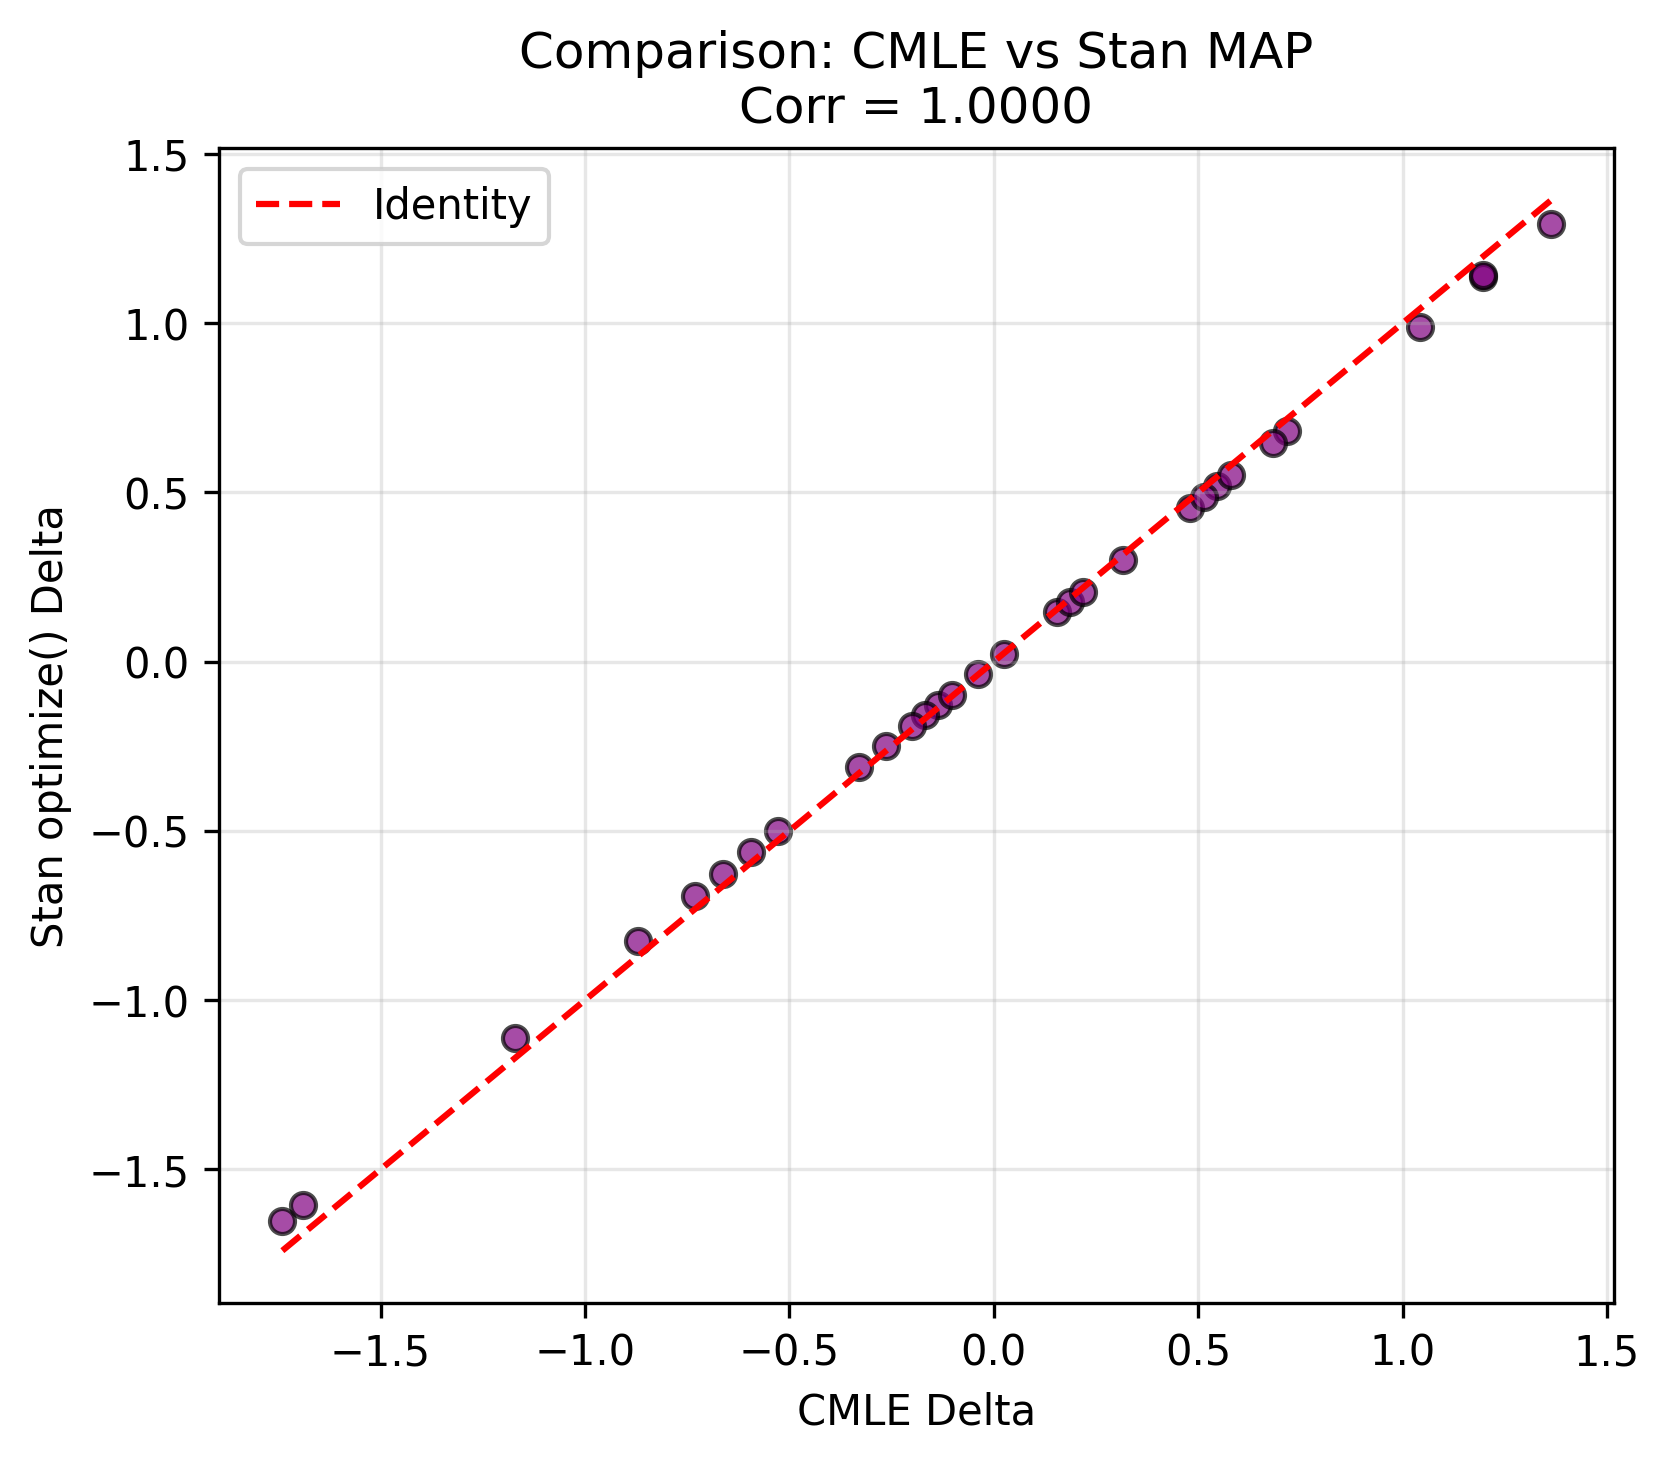

In [ ]:
import os
from cmdstanpy import CmdStanModel

# Define Stan model with hierarchical prior for person abilities (theta)
stan_rasch_code_fixed = """
// Generated from Week_09_KOS5101.ipynb
data {
  int<lower=1> N;             // number of persons
  int<lower=1> J;             // number of items
  array[N, J] int<lower=0, upper=1> X;
}
parameters {
  vector[N] theta;           // person abilities
  vector[J-1] delta_free;    // item difficulties (first J-1)
  real mu_theta;             // mean of person abilities (hyperparameter)
  real<lower=0> sigma_theta; // sd of person abilities (hyperparameter)
}
transformed parameters {
  vector[J] delta;
  delta[1:(J-1)] = delta_free;
  delta[J] = -sum(delta_free);  // Sum-to-zero constraint
}
model {
  // Hyperpriors
  mu_theta ~ normal(0, 5);
  sigma_theta ~ cauchy(0, 2);

  // Priors
  theta ~ normal(mu_theta, sigma_theta);
  delta_free ~ normal(0, 3);
  
  // Likelihood
  for (n in 1:N) {
     X[n] ~ bernoulli_logit(theta[n] - delta);
  }
}
"""

stan_file = 'rasch_simple.stan'
with open(stan_file, 'w') as f:
    f.write(stan_rasch_code_fixed)

# Compile the model
# force=True to ensure it picks up the fixed file if previous compilation failed
model = CmdStanModel(stan_file=stan_file, force_compile=True)

# Prepare data
stan_data = {
    'N': N_PERSON,
    'J': J_ITEM,
    'X': X
}

# Run optimize
print("Running CmdStanPy optimize()...")
mle_fit = model.optimize(data=stan_data, seed=SEED)

# Extract estimates
delta_stan_map = mle_fit.stan_variable('delta')
theta_stan_map = mle_fit.stan_variable('theta')

print("Stan MAP Delta (Item, first 5):", delta_stan_map[:5])

# Compare results (Items)
plt.figure(figsize=(6, 5))
plt.scatter(delta_cmle, delta_stan_map, alpha=0.7, color='purple', edgecolors='k')
plt.plot([delta_cmle.min(), delta_cmle.max()], [delta_cmle.min(), delta_cmle.max()], 'r--', label='Identity')
plt.xlabel('CMLE Delta')
plt.ylabel('Stan optimize() Delta')
plt.title(f'Comparison: CMLE vs Stan MAP\nCorr = {np.corrcoef(delta_cmle, delta_stan_map)[0,1]:.4f}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 4. Stan MCMC vs CMLE

We define a standard Rasch model in Stan:
$$ P(X_{ni}=1) = \text{logit}^{-1}(\theta_n - \delta_j) $$
To correct for the "floating scale," we constrain $\sum \delta_j = 0$ (sum-to-zero).
We use **weakly informative priors** (Standard Normal) to regularize the estimates, effectively performing MAP estimation.

Note: In small samples (short tests), JML (estimating $N+J$ params) can be biased. CMLE removes $\theta$ to estimate $\delta$. We expect Stan MAP estimates to be very close to CMLE if priors are flat, or slightly shrinkage-biased if J is small.

17:42:51 - cmdstanpy - INFO - CmdStan start processing


Running CmdStanPy sample()...


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

17:42:59 - cmdstanpy - INFO - CmdStan done processing.



MCMC finished.
MCMC Mean Delta (Item, first 5): [ 1.36627971  0.15335609  0.18554275  0.21702906 -0.73123051]
MCMC Mean Theta (Person, first 5): [ 0.84049071 -0.39731244 -0.40287588  1.48168711 -0.26002052]

--- Correlation Matrix of Delta Estimates ---
             True    CMLE  Stan_MAP  Stan_MCMC
True       1.0000  0.9699    0.9699     0.9699
CMLE       0.9699  1.0000    1.0000     1.0000
Stan_MAP   0.9699  1.0000    1.0000     1.0000
Stan_MCMC  0.9699  1.0000    1.0000     1.0000


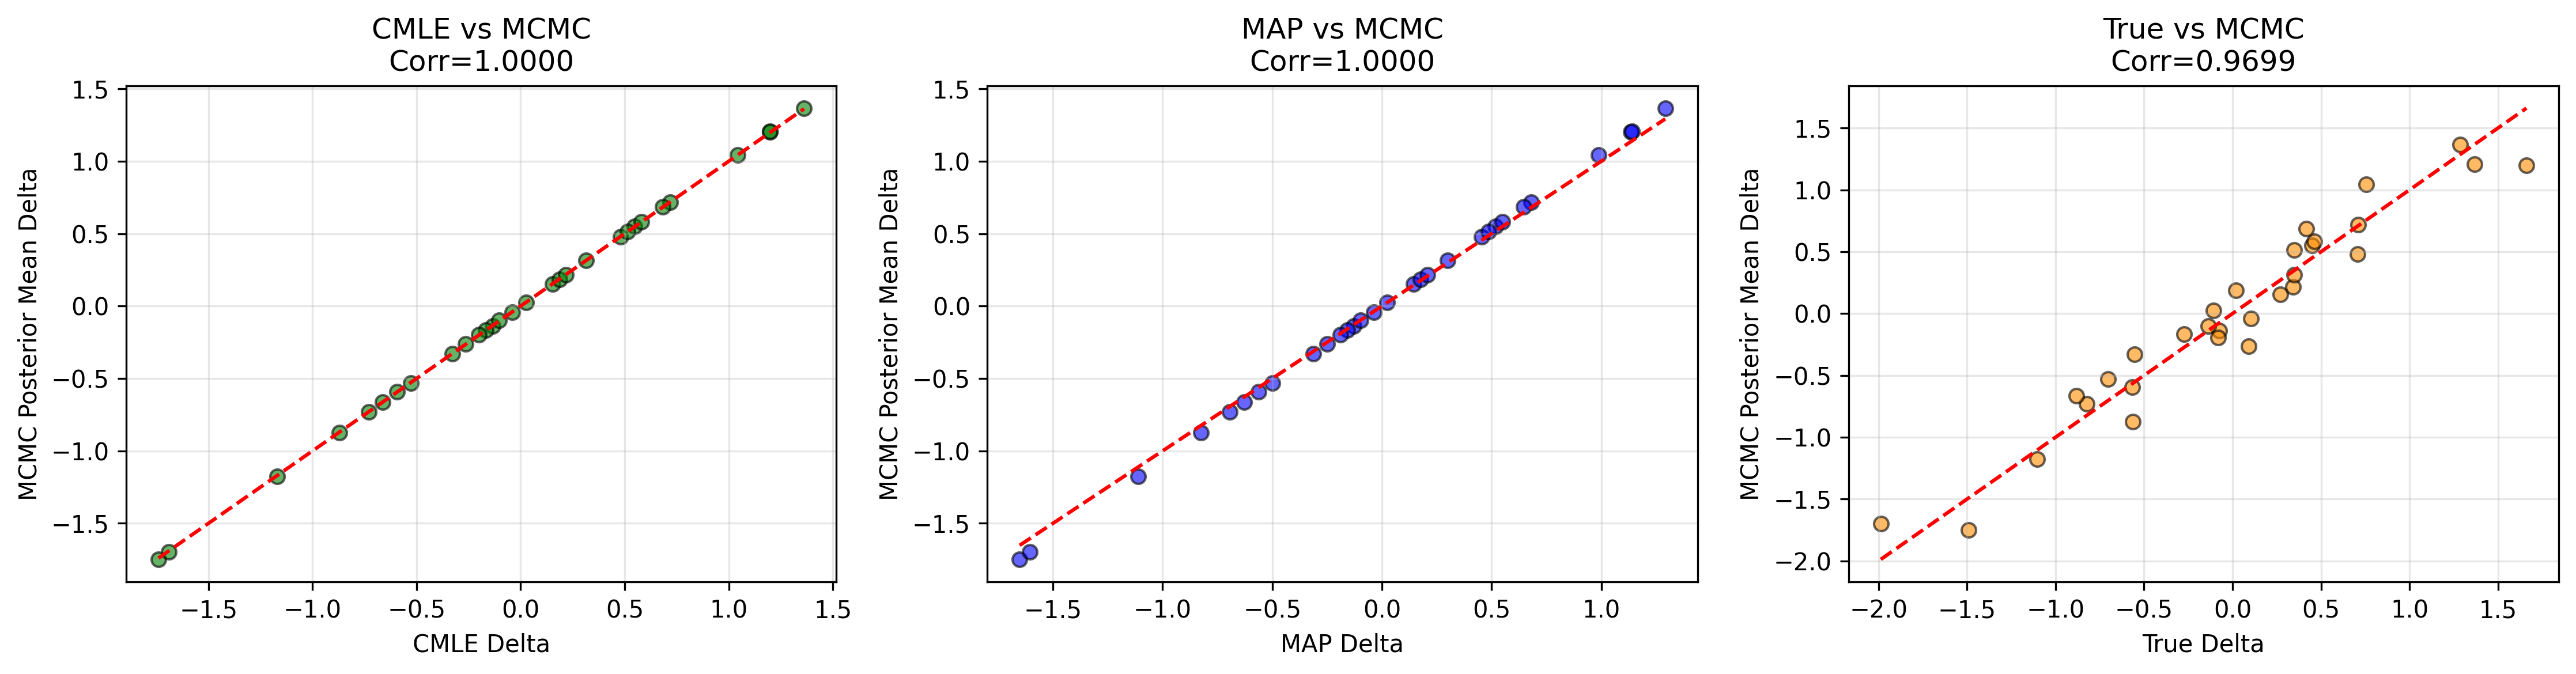

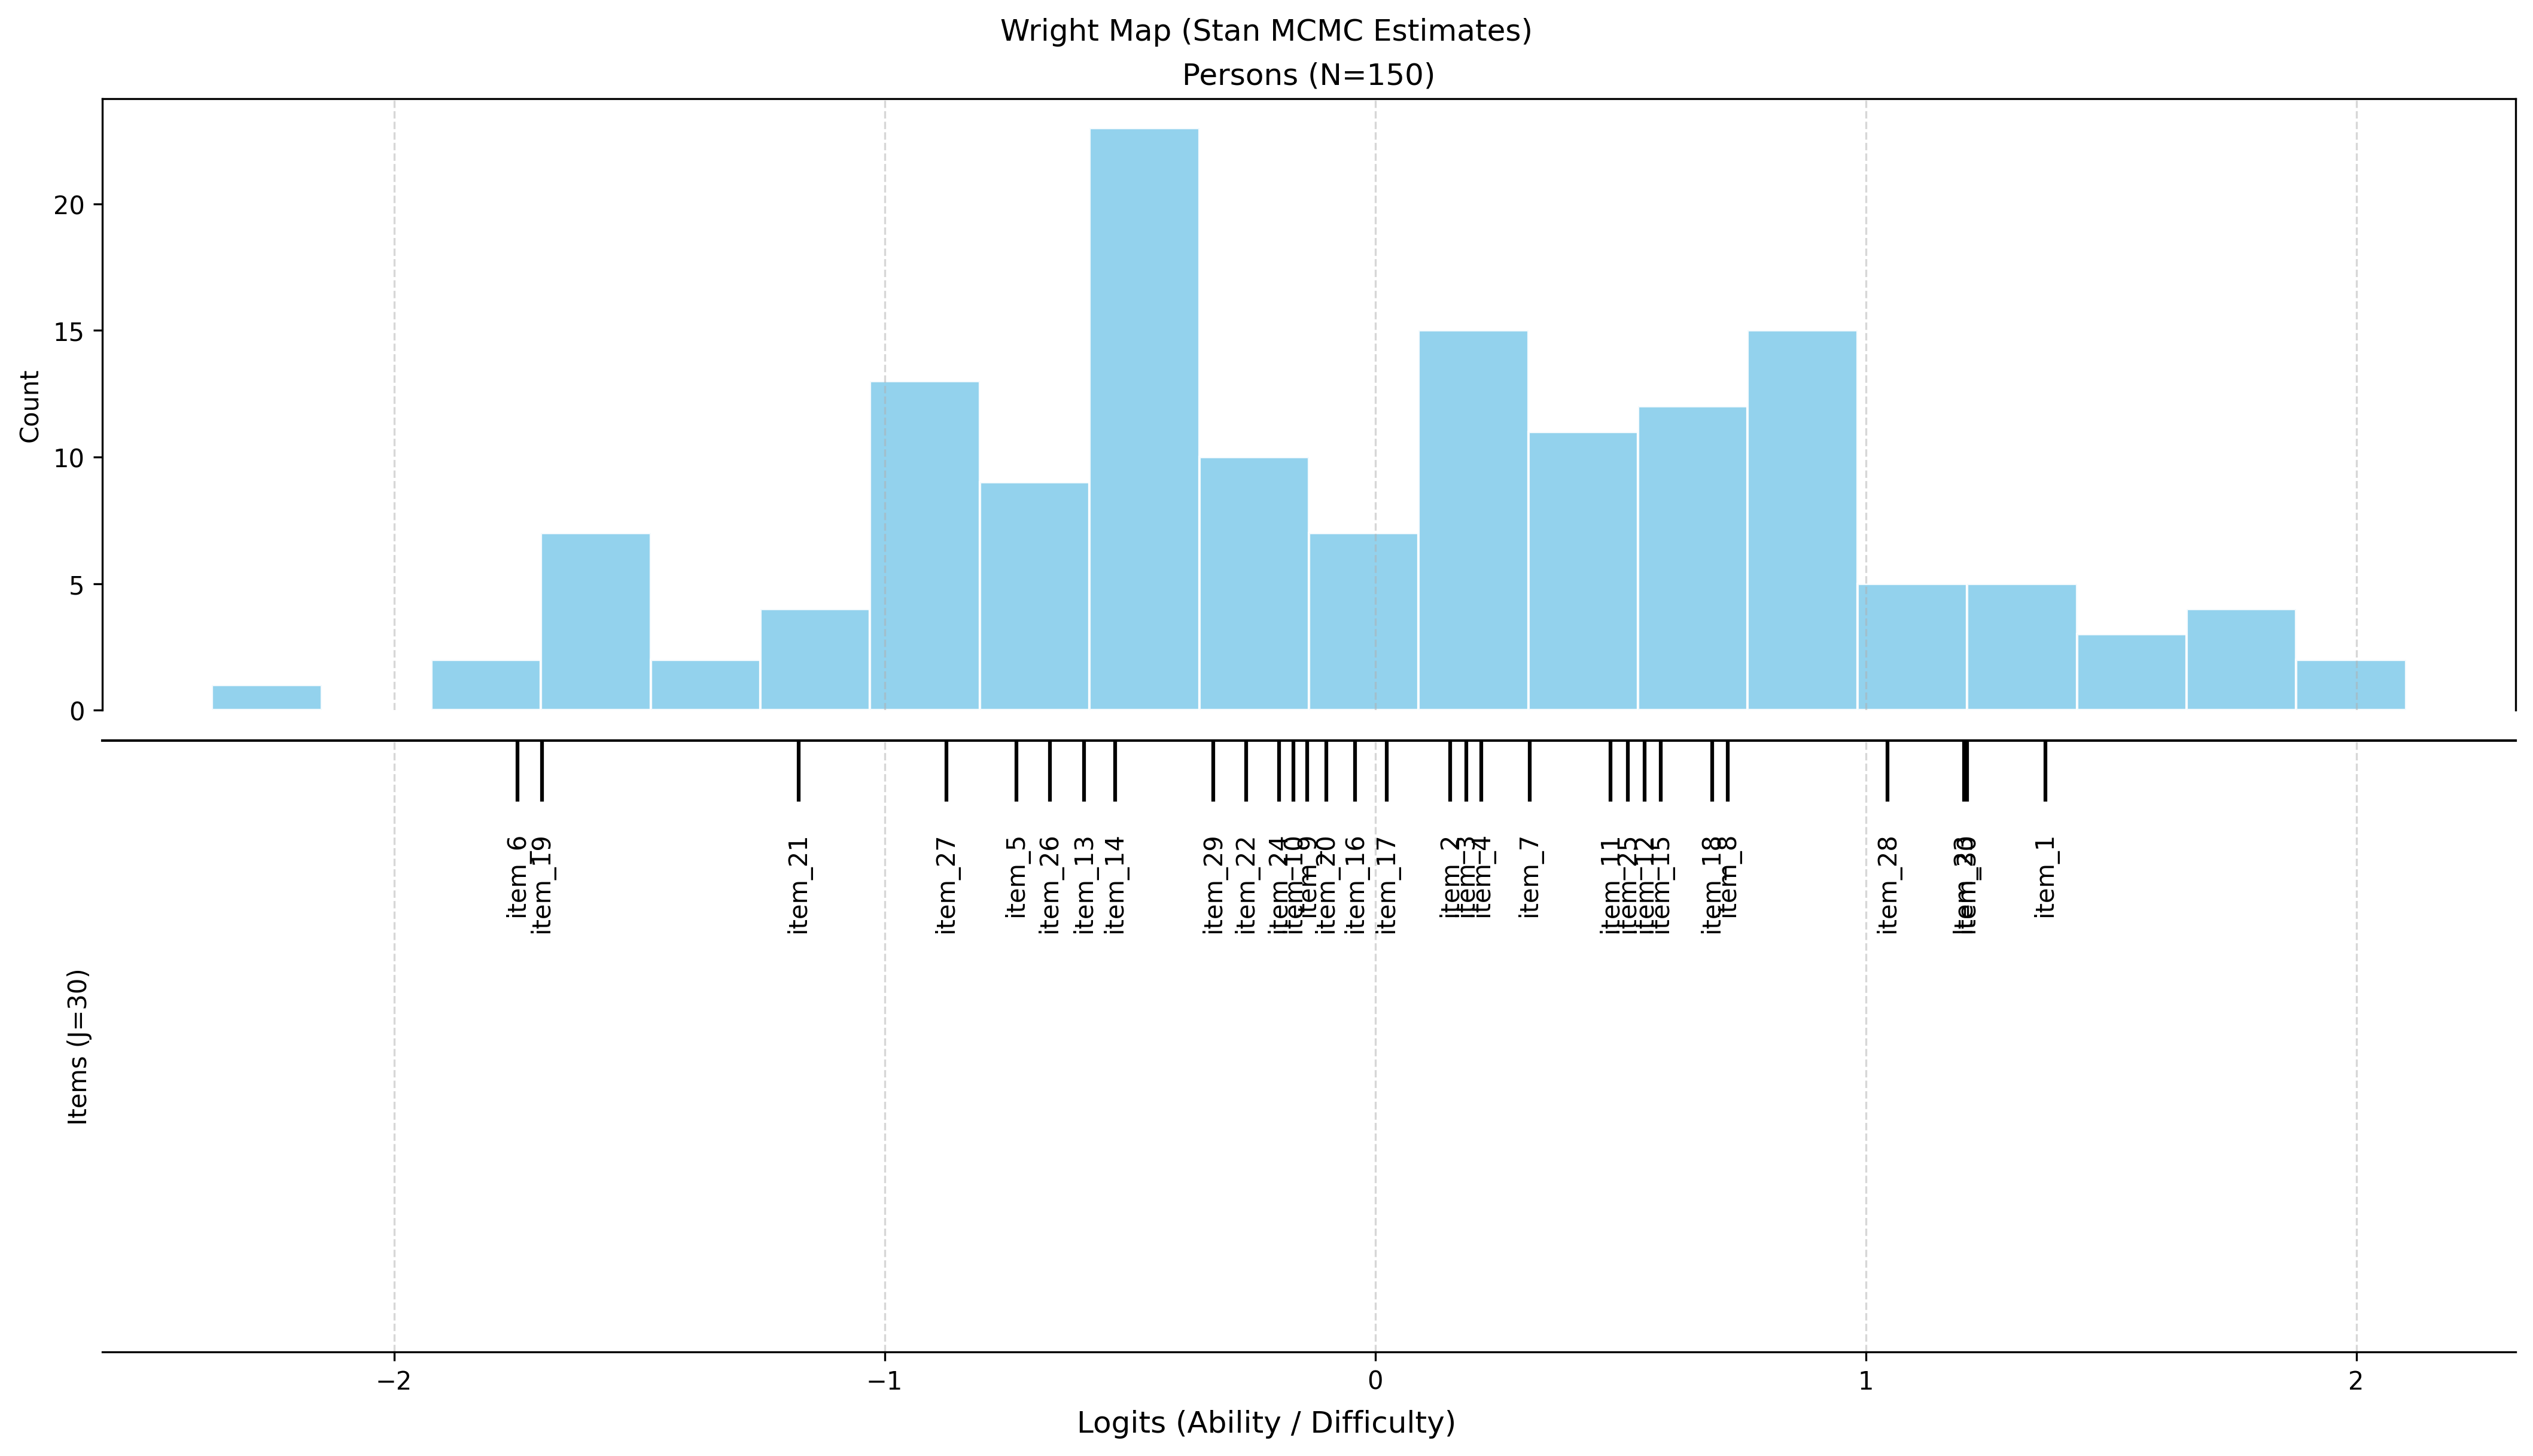

In [10]:
# Run MCMC Sampling
print("Running CmdStanPy sample()...")

fit_mcmc = model.sample(
    data=stan_data,
    iter_warmup=500,
    iter_sampling=1000,
    chains=4,
    parallel_chains=4,
    seed=SEED,
    max_treedepth=12,  # Increase detailed params for stability if needed
    adapt_delta=0.9,
    show_progress=True
)

print("MCMC finished.")

# Extract posterior means (point estimates)
delta_mcmc = fit_mcmc.stan_variable('delta').mean(axis=0)
theta_mcmc = fit_mcmc.stan_variable('theta').mean(axis=0)

print("MCMC Mean Delta (Item, first 5):", delta_mcmc[:5])
print("MCMC Mean Theta (Person, first 5):", theta_mcmc[:5])

# Compare all three estimators for Items (Delta)
df_compare = pd.DataFrame({
    'True': delta_true,
    'CMLE': delta_cmle,
    'Stan_MAP': delta_stan_map,
    'Stan_MCMC': delta_mcmc
})

print("\n--- Correlation Matrix of Delta Estimates ---")
print(df_compare.corr().round(4))

# Visual Comparison
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# CMLE vs MCMC
ax[0].scatter(delta_cmle, delta_mcmc, color='green', alpha=0.6, edgecolors='k')
ax[0].plot([delta_cmle.min(), delta_cmle.max()], [delta_cmle.min(), delta_cmle.max()], 'r--', label='Ideal')
ax[0].set_xlabel("CMLE Delta")
ax[0].set_ylabel("MCMC Posterior Mean Delta")
ax[0].set_title(f"CMLE vs MCMC\nCorr={np.corrcoef(delta_cmle, delta_mcmc)[0,1]:.4f}")
ax[0].grid(True, alpha=0.3)

# MAP vs MCMC
ax[1].scatter(delta_stan_map, delta_mcmc, color='blue', alpha=0.6, edgecolors='k')
ax[1].plot([delta_stan_map.min(), delta_stan_map.max()], [delta_stan_map.min(), delta_stan_map.max()], 'r--')
ax[1].set_xlabel("MAP Delta")
ax[1].set_ylabel("MCMC Posterior Mean Delta")
ax[1].set_title(f"MAP vs MCMC\nCorr={np.corrcoef(delta_stan_map, delta_mcmc)[0,1]:.4f}")
ax[1].grid(True, alpha=0.3)

# True vs MCMC
ax[2].scatter(delta_true, delta_mcmc, color='darkorange', alpha=0.6, edgecolors='k')
ax[2].plot([delta_true.min(), delta_true.max()], [delta_true.min(), delta_true.max()], 'r--')
ax[2].set_xlabel("True Delta")
ax[2].set_ylabel("MCMC Posterior Mean Delta")
ax[2].set_title(f"True vs MCMC\nCorr={np.corrcoef(delta_true, delta_mcmc)[0,1]:.4f}")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Wright Map with MCMC estimates (theta, delta)
plot_wright_map(theta_mcmc, delta_mcmc, title="Wright Map (Stan MCMC Estimates)")

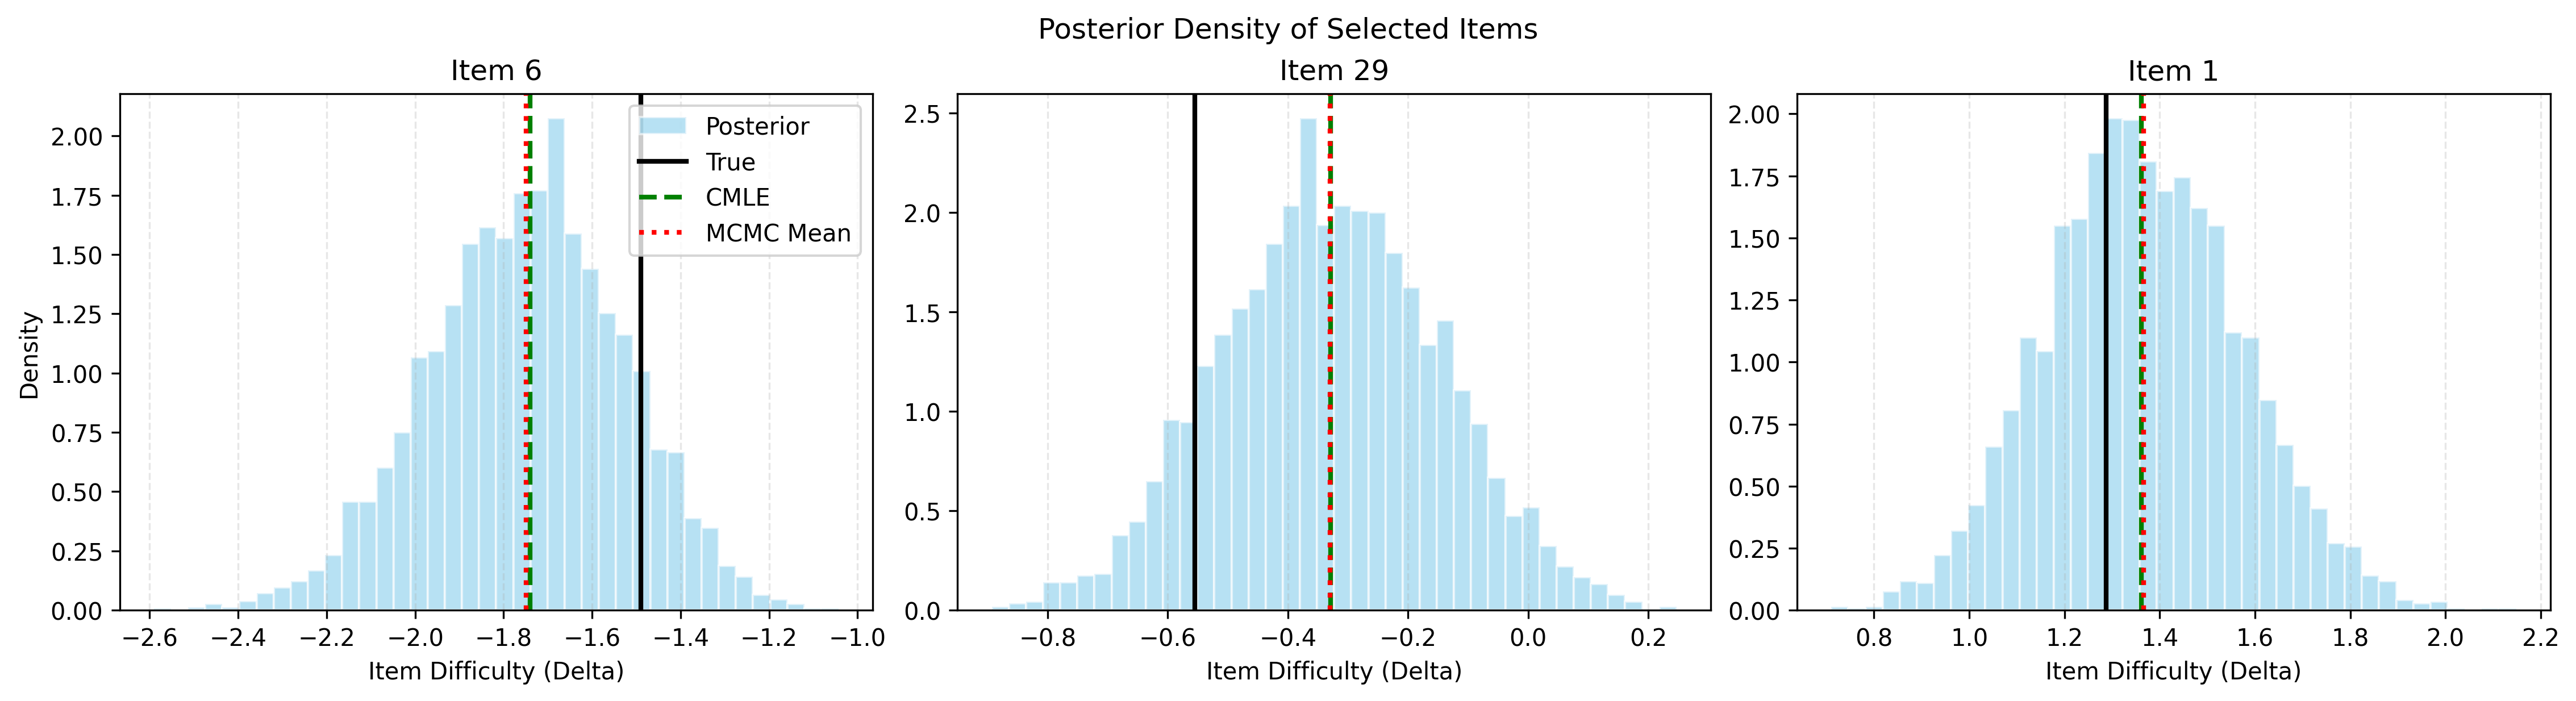

In [14]:
# Extract full posterior samples for delta
delta_samples_all = fit_mcmc.stan_variable('delta')

# Items to plot (1-based index -> 0-based index)
# Item 6 (idx 5), Item 29 (idx 28), Item 1 (idx 0)
item_indices = [5, 28, 0]
plot_titles = [f"Item {idx+1}" for idx in item_indices]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

for ax, idx, title in zip(axes, item_indices, plot_titles):
    # Plot posterior density
    ax.hist(delta_samples_all[:, idx], bins=40, density=True, 
            color='skyblue', alpha=0.6, edgecolor='white', label='Posterior')
    
    # Add vertical lines for comparison
    ax.axvline(delta_true[idx], color='black', linestyle='-', linewidth=2, label='True')
    ax.axvline(delta_cmle[idx], color='green', linestyle='--', linewidth=2, label='CMLE')
    ax.axvline(delta_mcmc[idx], color='red', linestyle=':', linewidth=2, label='MCMC Mean')
    
    ax.set_title(title)
    ax.set_xlabel("Item Difficulty (Delta)")
    ax.grid(axis='x', linestyle='--', alpha=0.3)

# Add legend to the first plot
axes[0].set_ylabel("Density")
axes[0].legend(loc='upper right')

plt.suptitle("Posterior Density of Selected Items")
plt.show()

# 6. Rasch Diagnostics: Infit & Outfit

Fit statistics help us identify items (or persons) that do not accord with the Rasch model expectations.

### Definitions
For each observation $X_{ni}$, we compute the expected value $E_{ni} = P_{ni}$ and variance $W_{ni} = P_{ni}(1-P_{ni})$.
The standardized residual is $Z_{ni} = \frac{X_{ni} - E_{ni}}{\sqrt{W_{ni}}}$.

**Outfit (Outlier-sensitive Fit) Mean Square**: Unweighted average of squared residuals. Sensitive to extreme unexpected responses (e.g., lucky guess).
$$ \text{Outfit}_i = \frac{1}{N} \sum_{n=1}^N Z_{ni}^2 $$

**Infit (Information-weighted Fit) Mean Square**: Weighted average, where weights are the model variance $W_{ni}$. Sensitive to on-target irregularities.
$$ \text{Infit}_i = \frac{\sum_{n=1}^N W_{ni} Z_{ni}^2}{\sum_{n=1}^N W_{ni}} $$

### Interpretation
*   **range:** $0$ to $\infty$. Expectation is $1.0$.
*   **> 1.5:** Underfitting (too much noise, erratic). Degrading measurement system.
*   **< 0.5:** Overfitting (too much predictability, Guttman-like). Deterministic; adds little new info but not harmful.
*   **0.5 - 1.5:** Productive for measurement.

Item Fit Statistics (first 5):
      Delta     Infit    Outfit
0  1.366280  1.020677  1.067788
1  0.153356  1.010217  1.006482
2  0.185543  0.905648  0.866545
3  0.217029  0.910513  0.872612
4 -0.731231  0.938500  0.912380

Summary of Item Infit:
count    30.000000
mean      0.954171
std       0.057642
min       0.860059
25%       0.908499
50%       0.954201
75%       0.996857
max       1.092614
Name: Infit, dtype: float64

Summary of Item Outfit:
count    30.000000
mean      0.924934
std       0.085596
min       0.772488
25%       0.873177
50%       0.913827
75%       0.992569
max       1.090267
Name: Outfit, dtype: float64


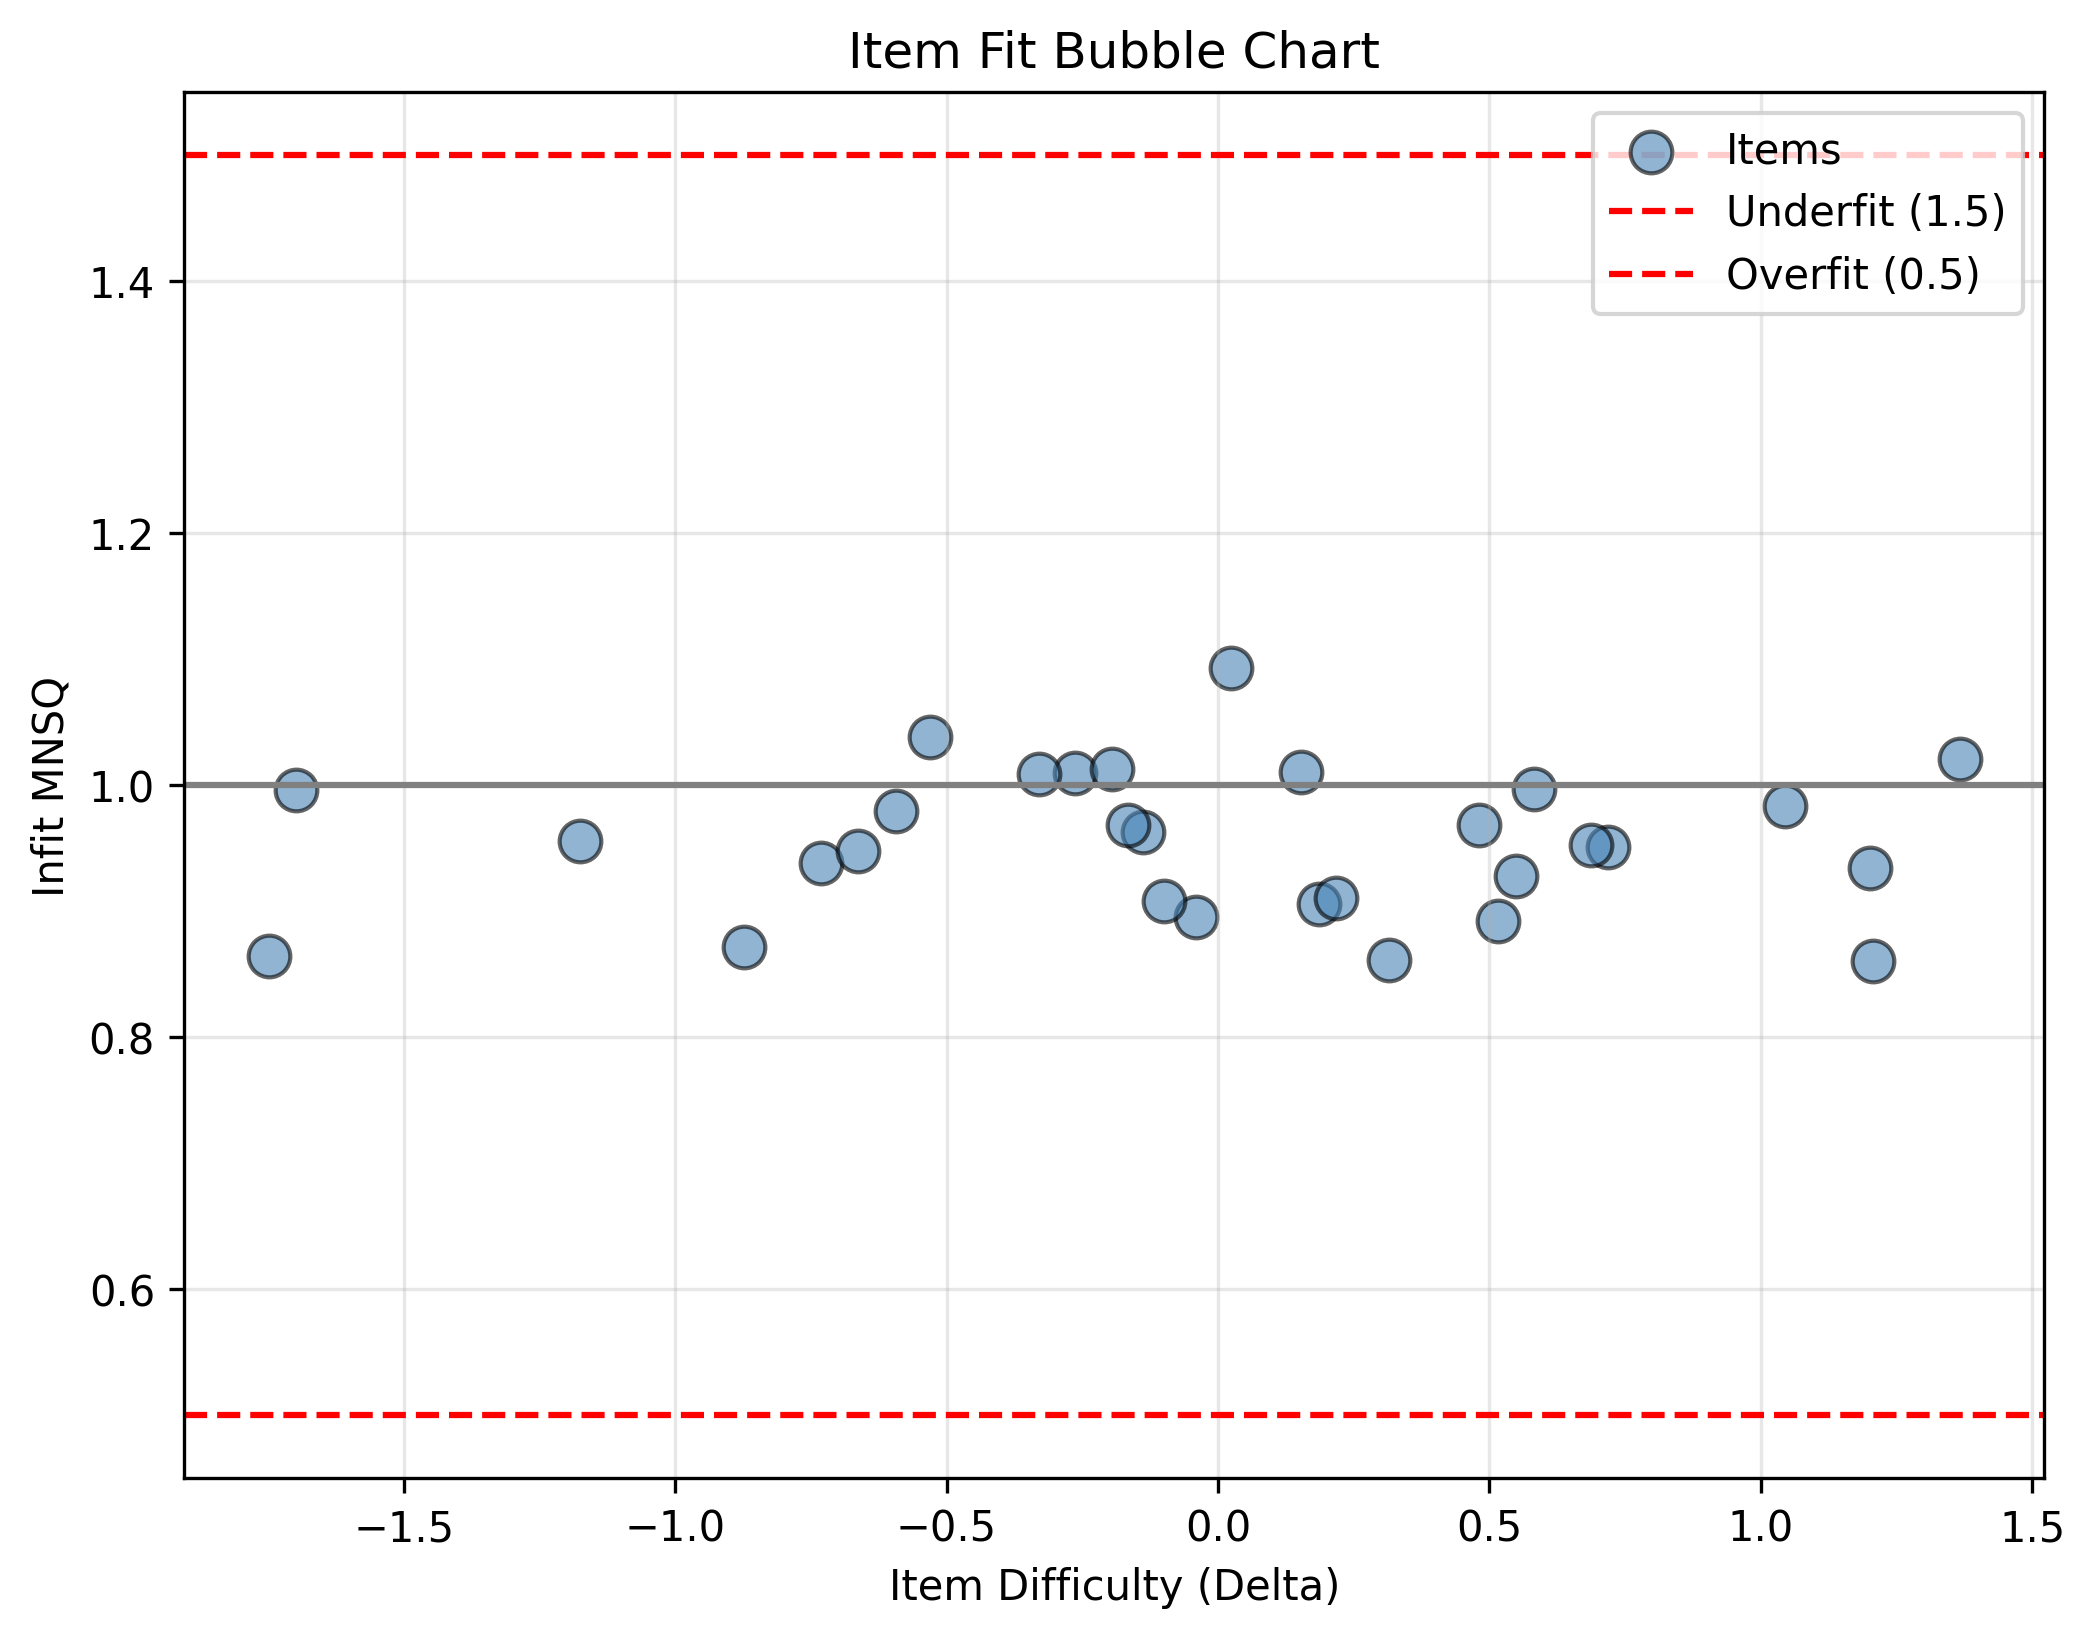

In [11]:
def compute_rasch_fit(X, thetas, deltas):
    # Vectors -> broadcasting
    # thetas (person): (N,), deltas (item): (J,)
    # Logit = theta_n - delta_j
    logit = thetas[:, None] - deltas[None, :]
    P = expit(logit)
    W = P * (1 - P)
    E = P
    
    # Residuals
    Z_sq = ((X - E) ** 2) / W
    
    # Item Fit (aggregate over persons n)
    # Outfit_i = sum_n(Z_ni^2) / N
    outfit_item = np.sum(Z_sq, axis=0) / X.shape[0]
    
    # Infit_i = sum_n(W_ni * Z_ni^2) / sum_n(W_ni)
    infit_item = np.sum(W * Z_sq, axis=0) / np.sum(W, axis=0)
    
    # Person Fit (aggregate over items j)
    # Outfit_n = sum_j(Z_ni^2) / J
    outfit_person = np.sum(Z_sq, axis=1) / X.shape[1]
    
    # Infit_n = sum_j(W_ni * Z_ni^2) / sum_j(W_ni)
    infit_person = np.sum(W * Z_sq, axis=1) / np.sum(W, axis=1)
    
    return (infit_item, outfit_item), (infit_person, outfit_person)

# Compute using MCMC estimates (theta=person, delta=item)
(item_infit, item_outfit), (person_infit, person_outfit) = compute_rasch_fit(X, theta_mcmc, delta_mcmc)

# Report Items
df_item_fit = pd.DataFrame({
    'Delta': delta_mcmc,
    'Infit': item_infit,
    'Outfit': item_outfit
})
print("Item Fit Statistics (first 5):")
print(df_item_fit.head())
print("\nSummary of Item Infit:")
print(df_item_fit['Infit'].describe())
print("\nSummary of Item Outfit:")
print(df_item_fit['Outfit'].describe())

# Plot Fit Bubble Chart (Pathway Map style for fit)
# Bond & Fox often use a plot where X=Measure, Y=Fit (Infit MNSQ)
plt.figure(figsize=(8, 6))
plt.scatter(delta_mcmc, item_infit, s=100, alpha=0.6, c='steelblue', label='Items', edgecolors='k')

# Add boundaries
plt.axhline(1.5, color='red', linestyle='--', label='Underfit (1.5)')
plt.axhline(0.5, color='red', linestyle='--', label='Overfit (0.5)')
plt.axhline(1.0, color='gray', linestyle='-')

# Annotate outliers
for i, (d, inf) in enumerate(zip(delta_mcmc, item_infit)):
    if inf > 1.4 or inf < 0.6:
        plt.text(d, inf, f"item_{i+1}", fontsize=9, ha='right')

plt.xlabel("Item Difficulty (Delta)")
plt.ylabel("Infit MNSQ")
plt.title("Item Fit Bubble Chart")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Invariance: Split-Sample Analysis

A fundamental property of the Rasch model is **parameter invariance**:
*   **Item Invariance**: Item difficulty estimates should be statistically independent of the specific sample of persons used to estimate them (e.g., high ability vs. low ability).
*   **Person Invariance**: Person ability estimates should be independent of the specific set of items used.

To test this, we perform a **Split-Sample Analysis**:
1.  Divide the sample into two groups based on raw scores (e.g., "Low Ability" vs. "High Ability").
2.  Estimate item parameters ($\delta$) separately for each group.
3.  Compare the two sets of estimates. If the model holds, they should be linearly related with a slope of 1 (falling on the identity line), within measurement error.

We will visualize this using a scatter plot with **uncertainty ellipses** (defined by posterior standard deviations).

### Statistical Significance (DIF)
To formally test for **Differential Item Functioning (DIF)**, we check if the parameters differ significantly between groups. Since the two groups are independent, the standard error of the *difference* is:
$$ SE(\delta_{low} - \delta_{high}) = \sqrt{SE(\delta_{low})^2 + SE(\delta_{high})^2} $$
The Z-statistic is the difference divided by this standard error. Even though the uncertainty is elliptical (2D), we are specifically testing the **distance from the diagonal identity line**. A value of $|Z| > 2$ limits implies the 95% confidence intervals do not overlap the identity line significantly.

In [12]:
# Split data based on median raw score
raw_scores = X.sum(axis=1)
median_score = np.median(raw_scores)

idx_low = raw_scores <= median_score
idx_high = raw_scores > median_score

X_low = X[idx_low]
X_high = X[idx_high]

print(f"Split Sample: Low Group N={X_low.shape[0]}, High Group N={X_high.shape[0]}")

# Prepare Stan data for subgroups
stan_data_low = {'N': X_low.shape[0], 'J': J_ITEM, 'X': X_low}
stan_data_high = {'N': X_high.shape[0], 'J': J_ITEM, 'X': X_high}

# Run MCMC for both groups (short chains for speed)
# We use the already compiled 'model'
print("Running MCMC for Low Group...")
fit_low = model.sample(data=stan_data_low, iter_warmup=500, iter_sampling=500, chains=2, parallel_chains=2, seed=SEED, show_progress=False)

print("Running MCMC for High Group...")
fit_high = model.sample(data=stan_data_high, iter_warmup=500, iter_sampling=500, chains=2, parallel_chains=2, seed=SEED, show_progress=False)

# Extract Posterior Means and SDs for Delta (Items)
def get_delta_stats(fit):
    # Extract all delta samples: shape (draws, J)
    delta_samples = fit.stan_variable('delta')
    return delta_samples.mean(axis=0), delta_samples.std(axis=0)

delta_low_mean, delta_low_sd = get_delta_stats(fit_low)
delta_high_mean, delta_high_sd = get_delta_stats(fit_high)

17:43:01 - cmdstanpy - INFO - CmdStan start processing


Split Sample: Low Group N=75, High Group N=75
Running MCMC for Low Group...


17:43:01 - cmdstanpy - INFO - Chain [1] start processing
17:43:01 - cmdstanpy - INFO - Chain [2] start processing
17:43:03 - cmdstanpy - INFO - Chain [1] done processing
17:43:03 - cmdstanpy - INFO - Chain [2] done processing
17:43:03 - cmdstanpy - INFO - CmdStan start processing
17:43:03 - cmdstanpy - INFO - Chain [1] start processing
17:43:03 - cmdstanpy - INFO - Chain [2] start processing


Running MCMC for High Group...


17:43:06 - cmdstanpy - INFO - Chain [2] done processing
17:43:06 - cmdstanpy - INFO - Chain [1] done processing


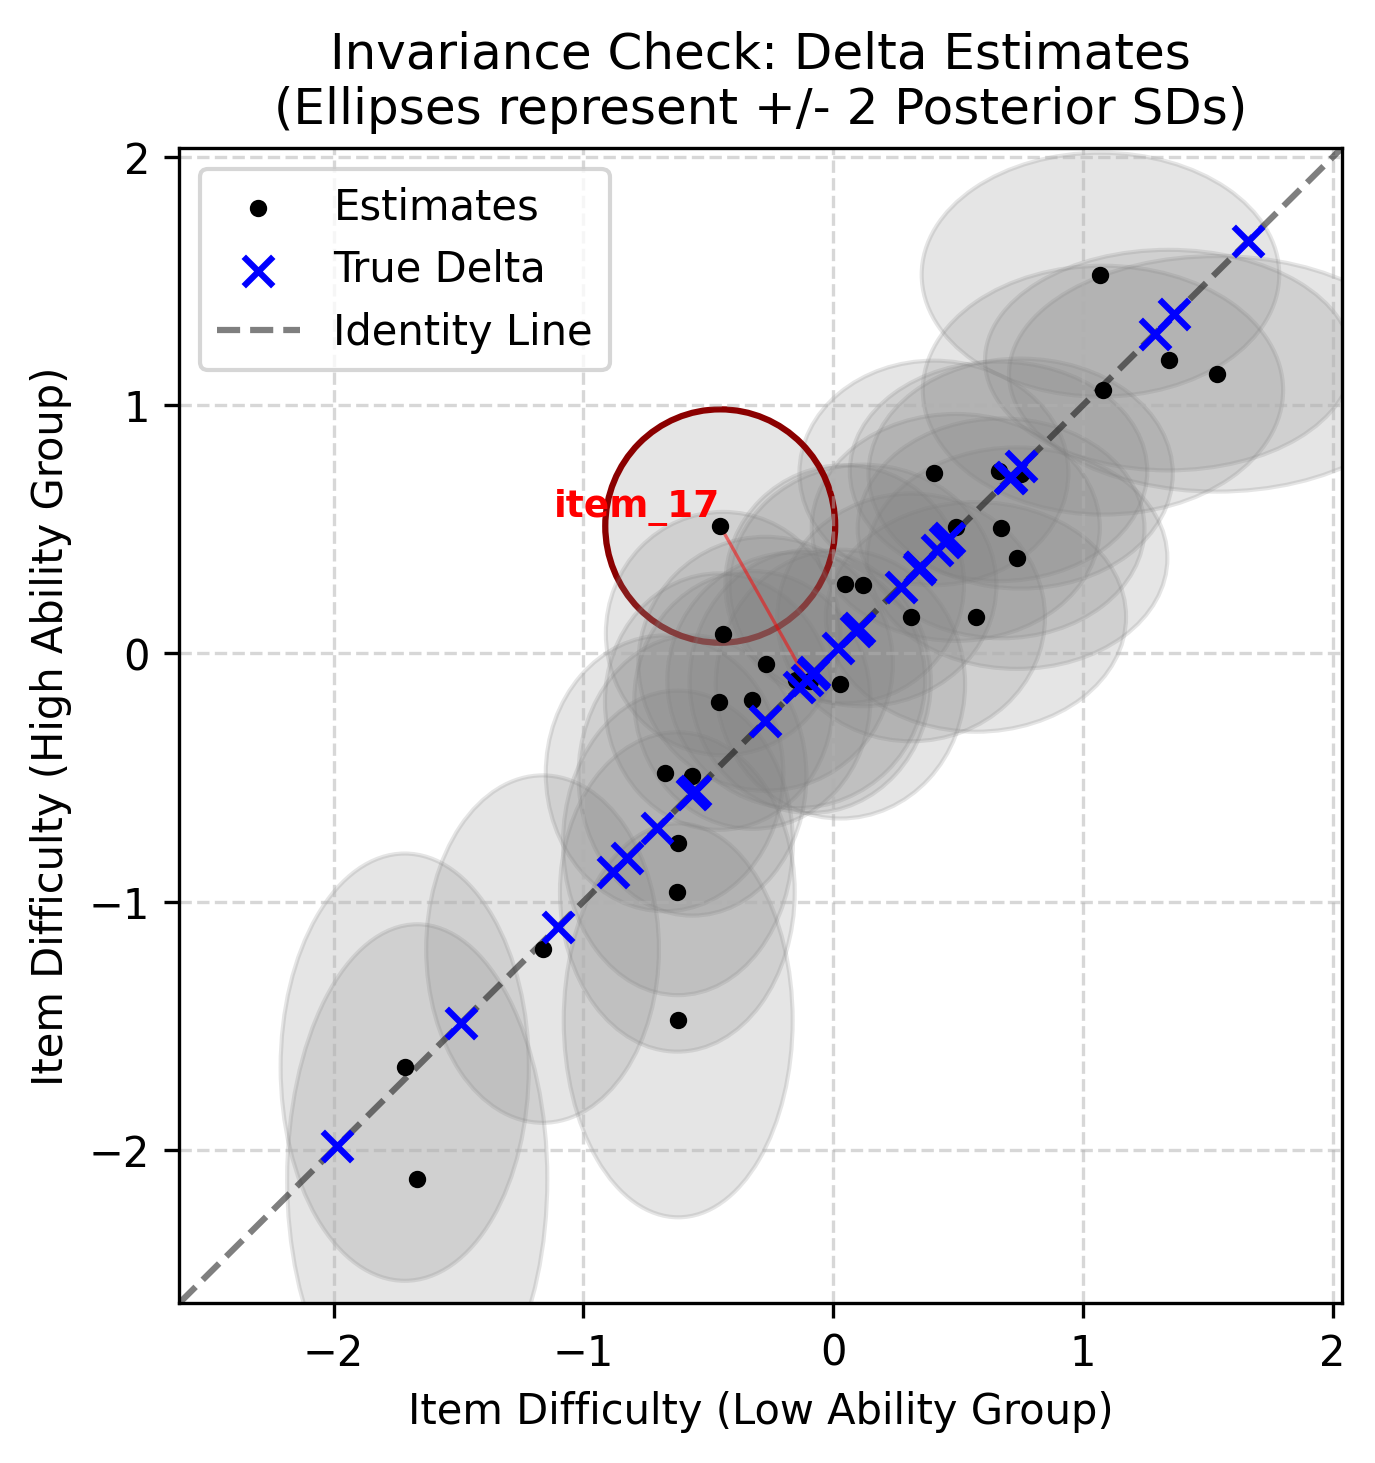

In [13]:
# Plotting Invariance Check
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(5, 5))

# Scatter plot
ax.scatter(delta_low_mean, delta_high_mean, color='black', s=10, zorder=5, label='Estimates')

# True values on diagonal
ax.scatter(delta_true, delta_true, color='blue', marker='x', s=50, label='True Delta', zorder=6)

# Identity line
min_val = min(delta_low_mean.min(), delta_high_mean.min()) - 0.5
max_val = max(delta_low_mean.max(), delta_high_mean.max()) + 0.5
lims = [min_val, max_val]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Identity Line')

# Draw Ellipses (Width = 4*SD_x, Height = 4*SD_y for +/- 2 SD coverage)
for i in range(len(delta_low_mean)):
    # Calculate DIF statistics (Z-score of the difference)
    # The SE of the difference (assuming independence) combines both SDs.
    diff = delta_low_mean[i] - delta_high_mean[i]
    se_diff = np.sqrt(delta_low_sd[i]**2 + delta_high_sd[i]**2)
    z = diff / se_diff
    is_sig = abs(z) > 2.0

    if is_sig:
        # Significant: Gray fill with Dark Red contour
        ell = Ellipse(
            xy=(delta_low_mean[i], delta_high_mean[i]),
            width=4 * delta_low_sd[i],
            height=4 * delta_high_sd[i],
            facecolor=(0.5, 0.5, 0.5, 0.2), # Gray fill with alpha 0.2
            edgecolor='darkred',            # Opaque dark red edge
            linewidth=1.5
        )
    else:
        # Non-significant: Gray fill, no edge
        ell = Ellipse(
            xy=(delta_low_mean[i], delta_high_mean[i]),
            width=4 * delta_low_sd[i],
            height=4 * delta_high_sd[i],
            color='gray',
            alpha=0.2
        )
        
    ax.add_patch(ell)
    
    # Label items with significant DIF
    if is_sig:
         ax.text(delta_low_mean[i], delta_high_mean[i], f"item_{i+1}", fontsize=9, color='red', fontweight='bold', ha='right', va='bottom')
         # Draw line segment between estimate and true
         ax.plot([delta_low_mean[i], delta_true[i]], [delta_high_mean[i], delta_true[i]], color='red', alpha=0.5, linestyle='-', linewidth=0.8)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Item Difficulty (Low Ability Group)")
ax.set_ylabel("Item Difficulty (High Ability Group)")
ax.set_title("Invariance Check: Delta Estimates\n(Ellipses represent +/- 2 Posterior SDs)")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.show()

# 8. References & Further Reading

1.  **Bond, T. G., & Fox, C. M. (2015).** *Applying the Rasch Model: Fundamental Measurement in the Human Sciences*. Routledge.
2.  **Wright, B. D., & Stone, M. H. (1979).** *Best Test Design*. MESA Press.
3.  **Stan Development Team.** *Stan User's Guide*. [https://mc-stan.org/docs/](https://mc-stan.org/docs/)
4.  **CmdStanPy Documentation.** [https://cmdstanpy.readthedocs.io/](https://cmdstanpy.readthedocs.io/)
5.  **Linacre, J. M.** *Winsteps Helper: Rasch Analysis Software*. [https://www.winsteps.com/](https://www.winsteps.com/)